In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Dropout, BatchNormalization, Flatten
from keras.callbacks import EarlyStopping, ModelCheckpoint

class IMG_P2M():
    """
    단채널 이미지 분류 모델\\
    필수 설치 패키지 => numpy, tensorflow, scikit-learn\\
    지정된 내용에 따라 데이터를 입력받으면 전처리, 모델링, 후처리까지 작성해주는 모델함수
    """

    def __init__(self):
        self.model=Sequential()
        self.callback = []

    def preprocessing(self, data, labels):
        '''전처리 진행하며 전처리된 데이터를 반환'''
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(data, labels, test_size=.2, random_state=42)
        self.tr_pre_data = self.X_train/255
        self.tt_pre_data = self.X_test/255
        return self.tr_pre_data, self.tt_pre_data, self.y_train, self.y_test
    
    def modeling(self, dataset, labels, layer_count, met: list=['acc']):
        '''
        ## 예시
        이미지 사이즈 설정: size=(256,256, 3), 기본값은 입력된 이미지 크기\\
        레이어 개수 설정: layer=2\\
        m.add(Conv2D(32, activation='relu'))\\
        m.add(Conv2D(64, activation='relu'))
        '''
        if len(dataset.shape) == 4:
            self.model.add(Input(shape=dataset.shape[1:]))
        else:
            dataset = dataset.reshape(-1,dataset.shape[1],dataset.shape[2], 1)
            self.model.add(Input(shape=dataset.shape[1:]))

        for i in range(1,layer_count+1):
            self.model.add(Conv2D(32+i,3,1, padding='same', activation='relu'))
            self.model.add(MaxPooling2D())
            self.model.add(BatchNormalization())
        self.model.add(Flatten())
        self.model.add(Dense(np.unique(labels).__len__(), activation='softmax'))
        self.model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=met)
        return self.model
    
    def postprocessing(self, input_data):
        '''후처리를 위한 함수, 디코딩을 통해 예측한 확률을 기반으로 한글화 진행'''
        idx = 0 if len(input_data.shape) == 2 else 1 # 데이터의 개수가 1개를 넘기면 1씩 추가
        pre_data = (input_data/255).reshape(-1, input_data.shape[0+idx], input_data.shape[1+idx], 1)
        self.pred = self.model.predict(pre_data)
        self.answer = np.array(['티셔츠_상의','바지','풀오버','드레스','코트','샌들','셔츠','운동화','가방','앵클' '부츠'])
        self.decode_answer = self.answer[[np.argmax(p) for p in self.pred]]
        return self.decode_answer

    def auto_train(self, img, labels, layer_count: int=3, metrics: list=[], epoch: int=10, \
               batch_size: int=None, early_stop: int=5, check_filename: str=None):
        
        # 콜백함수 생성
        if early_stop != -1:
            es = EarlyStopping(patience=early_stop, restore_best_weights=True)
            self.callback.append(es)
        if check_filename:
            ch = ModelCheckpoint(check_filename, save_best_only=True)
            self.callback.append(ch)

        # 전처리 - 모델링 - 학습 - 후처리 진행
        tr_pre, tt_pre, tr_y, tt_y = self.preprocessing(img, labels)
        self.model = self.modeling(tr_pre, tr_y, layer_count, metrics)
        self.hy = self.model.fit(tr_pre, tr_y, epochs=epoch, validation_split=.2, batch_size=batch_size, callbacks=self.callback)
        print(self.model.evaluate(tr_pre, tr_y))
        print(self.model.evaluate(tt_pre, tt_y))
        return [self.hy, self.model]

In [7]:
from keras.datasets import fashion_mnist

(X,y), (_,_) = fashion_mnist.load_data()
X.shape, y.shape

((60000, 28, 28), (60000,))

Epoch 1/2
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - acc: 0.8460 - loss: 0.4294 - val_acc: 0.8851 - val_loss: 0.3202
Epoch 2/2
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - acc: 0.8959 - loss: 0.2906 - val_acc: 0.8959 - val_loss: 0.2864
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.9053 - loss: 0.2586
[0.25856876373291016, 0.9052500128746033]
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8919 - loss: 0.2918
[0.2918301522731781, 0.8919166922569275]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
[[1.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 6.6058924e-16
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [1.0000000e+00 3.6448028e-27 0.0000000e+00 0.0000000e+00 0.0000000e+00
  0.0000000e+00 2.0690711e-24 0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00 0.0000000e+00 0.0000

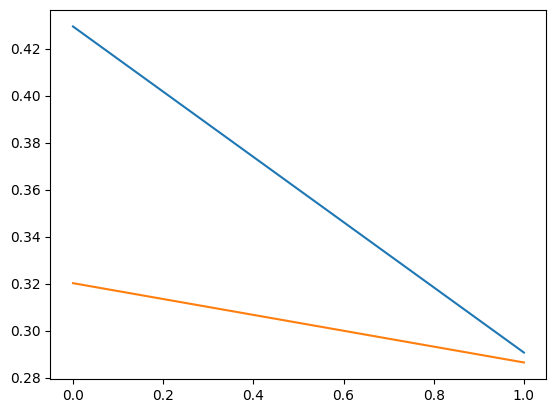

In [8]:
data = IMG_P2M()
res = data.auto_train(X, y, epoch=2, metrics=['acc'])
print(res[1].predict(X[2:7]))
plt.plot(res[0].history['loss'])
plt.plot(res[0].history['val_loss'])

In [9]:
data.postprocessing(X[3:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


array(['셔츠', '셔츠', '풀오버', '운동화', '풀오버', '샌들', '샌들'], dtype='<U6')